In [ ]:
import pandas as pd

df = pd.read_csv("../data/events_eda.csv")

print(df.shape)

df.head()

(8173, 56)


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,hour,day_of_week,month,year,duration_hours,cause_score,closure_score,priority_score,impact_score,risk_level
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,17.0,Thursday,3.0,2024.0,NaN,2.0,0,5.0,7.0,Medium
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,4.0,Tuesday,1.0,2024.0,NaN,2.0,0,5.0,7.0,Medium
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,6.0,Saturday,11.0,2023.0,NaN,3.0,0,1.0,4.0,Low
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,17.0,Thursday,3.0,2024.0,NaN,5.0,5,1.0,11.0,High
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,...,4.0,Tuesday,1.0,2024.0,NaN,2.0,0,1.0,3.0,Low


In [14]:
df["start_datetime"] = pd.to_datetime(
    df["start_datetime"],
    errors="coerce"
)
df["start_datetime"].head()

0   2024-03-07 17:01:48.111000+00:00
1   2024-01-30 04:07:24.173000+00:00
2   2023-11-11 06:18:03.343000+00:00
3   2024-03-07 17:56:55.061000+00:00
4   2024-01-30 04:56:32.348000+00:00
Name: start_datetime, dtype: datetime64[ns, UTC]

In [15]:
df["hour"] = df["start_datetime"].dt.hour

df["day_of_week"] = df["start_datetime"].dt.dayofweek

df["month"] = df["start_datetime"].dt.month

df["year"] = df["start_datetime"].dt.year

df["weekend"] = (
    df["day_of_week"]
    .isin([5, 6])
    .astype(int)
)

In [16]:
df[
    [
        "hour",
        "day_of_week",
        "month",
        "year",
        "weekend"
    ]
].head()

,hour,day_of_week,month,year,weekend
0,17.0,3.0,3.0,2024.0,0
1,4.0,1.0,1.0,2024.0,0
2,6.0,5.0,11.0,2023.0,1
3,17.0,3.0,3.0,2024.0,0
4,4.0,1.0,1.0,2024.0,0


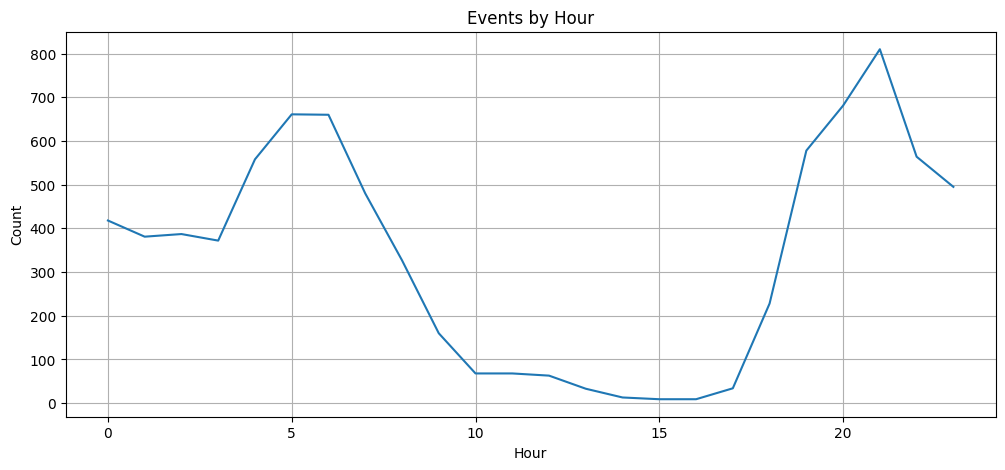

In [17]:
import matplotlib.pyplot as plt

hour_counts = (
    df["hour"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,5))

hour_counts.plot()

plt.title("Events by Hour")

plt.xlabel("Hour")

plt.ylabel("Count")

plt.grid()

plt.show()

In [18]:
pd.crosstab(
    df["event_cause"],
    df["risk_level"]
)

risk_level,Critical,High,Low,Medium
event_cause,,,,
Debris,0,0,3,9
Fog / Low Visibility,0,0,1,1
accident,5,169,0,191
congestion,2,96,0,38
construction,68,293,0,119
debris,0,1,0,0
others,0,30,233,375
pot_holes,0,5,230,302
procession,19,53,0,0


In [19]:
pd.crosstab(
    df["zone"],
    df["risk_level"]
)

risk_level,Critical,High,Low,Medium
zone,,,,
Central Zone 1,7,43,39,180
Central Zone 2,12,40,233,338
East Zone 1,3,63,62,125
East Zone 2,5,10,86,89
North Zone 1,14,76,38,190
North Zone 2,6,43,58,306
South Zone 1,2,13,86,132
South Zone 2,7,34,67,246
West Zone 1,8,35,126,264


In [20]:
df["lat_grid"] = (
    df["latitude"]
    .round(2)
)

df["lon_grid"] = (
    df["longitude"]
    .round(2)
)

In [21]:
df[
    [
        "latitude",
        "longitude",
        "lat_grid",
        "lon_grid"
    ]
].head()

,latitude,longitude,lat_grid,lon_grid
0,13.040004,77.518099,13.04,77.52
1,12.921876,77.645158,12.92,77.65
2,12.955622,77.585708,12.96,77.59
3,13.006147,77.579435,13.01,77.58
4,12.953980,77.585233,12.95,77.59


In [22]:
hotspots = (
    df.groupby(
        ["lat_grid", "lon_grid"]
    )
    .size()
    .reset_index(name="count")
    .sort_values(
        "count",
        ascending=False
    )
)

hotspots.head(20)

,lat_grid,lon_grid,count
284,13.00,77.58,137
212,12.97,77.59,136
220,12.97,77.70,136
235,12.98,77.59,128
236,12.98,77.60,122
345,13.03,77.54,116
164,12.95,77.54,114
233,12.98,77.57,109
112,12.92,77.62,105
307,13.01,77.58,96


In [23]:
features_to_keep = [
    "event_type",
    "event_cause",
    "requires_road_closure",
    "priority",
    "zone",
    "junction",
    "latitude",
    "longitude",
    "hour",
    "day_of_week",
    "month",
    "weekend",
    "risk_level"
]

clean_df = df[features_to_keep].copy()

In [27]:
df["day_of_week"].head()

0    3.0
1    1.0
2    5.0
3    3.0
4    1.0
Name: day_of_week, dtype: float64

In [28]:
df.to_csv(
    "../data/events_features.csv",
    index=False
)

In [29]:
df.columns.tolist()

['id',
 'event_type',
 'latitude',
 'longitude',
 'endlatitude',
 'endlongitude',
 'address',
 'end_address',
 'event_cause',
 'requires_road_closure',
 'start_datetime',
 'end_datetime',
 'status',
 'authenticated',
 'modified_datetime',
 'map_file',
 'direction',
 'description',
 'veh_type',
 'veh_no',
 'corridor',
 'priority',
 'cargo_material',
 'reason_breakdown',
 'age_of_truck',
 'created_date',
 'route_path',
 'client_id',
 'created_by_id',
 'last_modified_by_id',
 'assigned_to_police_id',
 'citizen_accident_id',
 'comment',
 'police_station',
 'meta_data',
 'kgid',
 'resolved_at_address',
 'resolved_at_latitude',
 'resolved_at_longitude',
 'closed_by_id',
 'closed_datetime',
 'resolved_by_id',
 'resolved_datetime',
 'gba_identifier',
 'zone',
 'junction',
 'hour',
 'day_of_week',
 'month',
 'year',
 'duration_hours',
 'cause_score',
 'closure_score',
 'priority_score',
 'impact_score',
 'risk_level',
 'weekend',
 'lat_grid',
 'lon_grid']

In [30]:
test_df = pd.read_csv(
    "../data/events_features.csv"
)

print(test_df.shape)

print(test_df.columns.tolist())

(8173, 59)
['id', 'event_type', 'latitude', 'longitude', 'endlatitude', 'endlongitude', 'address', 'end_address', 'event_cause', 'requires_road_closure', 'start_datetime', 'end_datetime', 'status', 'authenticated', 'modified_datetime', 'map_file', 'direction', 'description', 'veh_type', 'veh_no', 'corridor', 'priority', 'cargo_material', 'reason_breakdown', 'age_of_truck', 'created_date', 'route_path', 'client_id', 'created_by_id', 'last_modified_by_id', 'assigned_to_police_id', 'citizen_accident_id', 'comment', 'police_station', 'meta_data', 'kgid', 'resolved_at_address', 'resolved_at_latitude', 'resolved_at_longitude', 'closed_by_id', 'closed_datetime', 'resolved_by_id', 'resolved_datetime', 'gba_identifier', 'zone', 'junction', 'hour', 'day_of_week', 'month', 'year', 'duration_hours', 'cause_score', 'closure_score', 'priority_score', 'impact_score', 'risk_level', 'weekend', 'lat_grid', 'lon_grid']
